In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import scanpy as sc
import torch
import scarches as sca
from scarches.dataset.trvae.data_handling import remove_sparsity
import matplotlib.pyplot as plt
import numpy as np
import gdown

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [3]:
import pandas as pd

In [4]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

## load query

In [5]:
haniffaAd = sc.read_h5ad('haniffalab.h5ad')

In [6]:
haniffaAd.obs.columns

Index(['Status', 'Site', 'Tissue', 'Enrichment', 'Location', 'donor_id', 'Sex',
       'Age', 'stage', 'final_clustering'],
      dtype='object')

In [7]:
haniffaAd.obs["final_clustering"].value_counts()

nan                       88368
Differentiated_KC         62258
Th                        56000
Proliferating_KC          32550
VE2                       29738
F2                        28159
Undifferentiated_KC*      21726
Differentiated_KC*        20420
F1                        18747
Tc                        16090
VE1                       14719
F3                        13638
Pericyte_1_non_inflamm    13410
Treg                      13170
Inf_mono                   8401
Melanocyte                 8231
moDC_1                     7698
Macro_1                    7396
Mono                       7226
LC_3                       6328
LC_4                       5930
moDC_2                     5549
Pericyte_2_inflamm         5391
DC2                        5348
LE2                        5151
LC_2                       4965
MigDC                      4592
VE3                        4120
ILC1_3                     3940
moDC_3                     3835
ILC1_NK                    3342
Macro_2 

In [8]:
removed_cells = ['Differentiated_KC', 'Proliferating_KC', 'VE2', 'F2', 'Undifferentiated_KC*',
                                                           'Differentiated_KC*', 'F1', 'VE1', 'F3', 'Pericyte_1_non_inflamm', 'Melanocyte',
                                                           'LC_3', 'LC_4', 'VE3', 'LE1', 'LC_1', 'Schwann1', 'Schwann2']

In [9]:
removed_cells

['Differentiated_KC',
 'Proliferating_KC',
 'VE2',
 'F2',
 'Undifferentiated_KC*',
 'Differentiated_KC*',
 'F1',
 'VE1',
 'F3',
 'Pericyte_1_non_inflamm',
 'Melanocyte',
 'LC_3',
 'LC_4',
 'VE3',
 'LE1',
 'LC_1',
 'Schwann1',
 'Schwann2']

In [10]:
haniffaAd = haniffaAd[~haniffaAd.obs.final_clustering.isin(removed_cells)]

In [11]:
haniffaAd.var = haniffaAd.var[['gene_ids-SKN8090524', 'feature_types-SKN8090524']]

In [12]:
haniffaAd.obs["tissue"] = haniffaAd.obs.Tissue

In [13]:
haniffaAd.obs.columns = ['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 
                         'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue']

In [14]:
adata_query = haniffaAd.copy()

In [15]:
del haniffaAd

adata_query

AnnData object with n_obs × n_vars = 254314 × 33538
    obs: 'disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue'
    var: 'gene_ids-SKN8090524', 'feature_types-SKN8090524'

## load reference

In [16]:
adata_ref = sc.read_h5ad("Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad")

In [17]:
commonGen = [gen for gen in adata_query.var_names if gen in adata_ref.var_names]

In [18]:
commonGen[:10]

['FAM87B',
 'LINC00115',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223']

In [19]:
adata_ref = adata_ref[:, commonGen]

In [20]:
adata_ref

View of AnnData object with n_obs × n_vars = 365203 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_c

In [21]:
sc.pp.highly_variable_genes(
    adata_ref,
    n_top_genes=2000,
    batch_key="dataset_id",
    subset=True)

In [22]:
adata_ref.X = adata_ref.raw[:, adata_ref.var_names].X

In [23]:
adata_query = adata_query[:, adata_ref.var_names]

In [24]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

## SCVI model

In [25]:
sca.models.SCVI.setup_anndata(adata_ref,  batch_key="donor_id", labels_key="Cell_type_scANVI")

In [26]:
vae = sca.models.SCVI(
    adata_ref,
    n_layers=3,
    encode_covariates=True,
    deeply_inject_covariates=False,
    use_layer_norm="both",
    use_batch_norm="none",
)

In [27]:
early_stopping_kwargs = {
    #"early_stopping_metric": "elbo",
    "save_best_state_metric": "elbo",
    "patience": 10,
    "threshold": 0,
    "reduce_lr_on_plateau": True,
    "lr_patience": 8,
    "lr_factor": 0.1,
}
vae.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 22/22: 100%|██████████| 22/22 [12:51<00:00, 34.97s/it, v_num=1, train_loss_step=482, train_loss_epoch=479]

INFO: `Trainer.fit` stopped: `max_epochs=22` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=22` reached.


Epoch 22/22: 100%|██████████| 22/22 [12:51<00:00, 35.06s/it, v_num=1, train_loss_step=482, train_loss_epoch=479]


In [28]:
scanvae = sca.models.SCANVI.from_scvi_model(vae, unlabeled_category = "Unknown")

In [29]:
print("Labelled Indices: ", len(scanvae._labeled_indices))
print("Unlabelled Indices: ", len(scanvae._unlabeled_indices))

Labelled Indices:  365203
Unlabelled Indices:  0


In [30]:
scanvae.train()

INFO     Training for 7 epochs.                                                                                    


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 7/7: 100%|██████████| 7/7 [10:26<00:00, 88.73s/it, v_num=1, train_loss_step=510, train_loss_epoch=506]

INFO: `Trainer.fit` stopped: `max_epochs=7` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.


Epoch 7/7: 100%|██████████| 7/7 [10:26<00:00, 89.53s/it, v_num=1, train_loss_step=510, train_loss_epoch=506]


In [31]:
reference_latent = sc.AnnData(scanvae.get_latent_representation())
reference_latent.obs["Cell_type_scANVI"] = adata_ref.obs["Cell_type_scANVI"].tolist()
reference_latent.obs["dataset_id"] = adata_ref.obs["Cell_type_scANVI"].tolist()


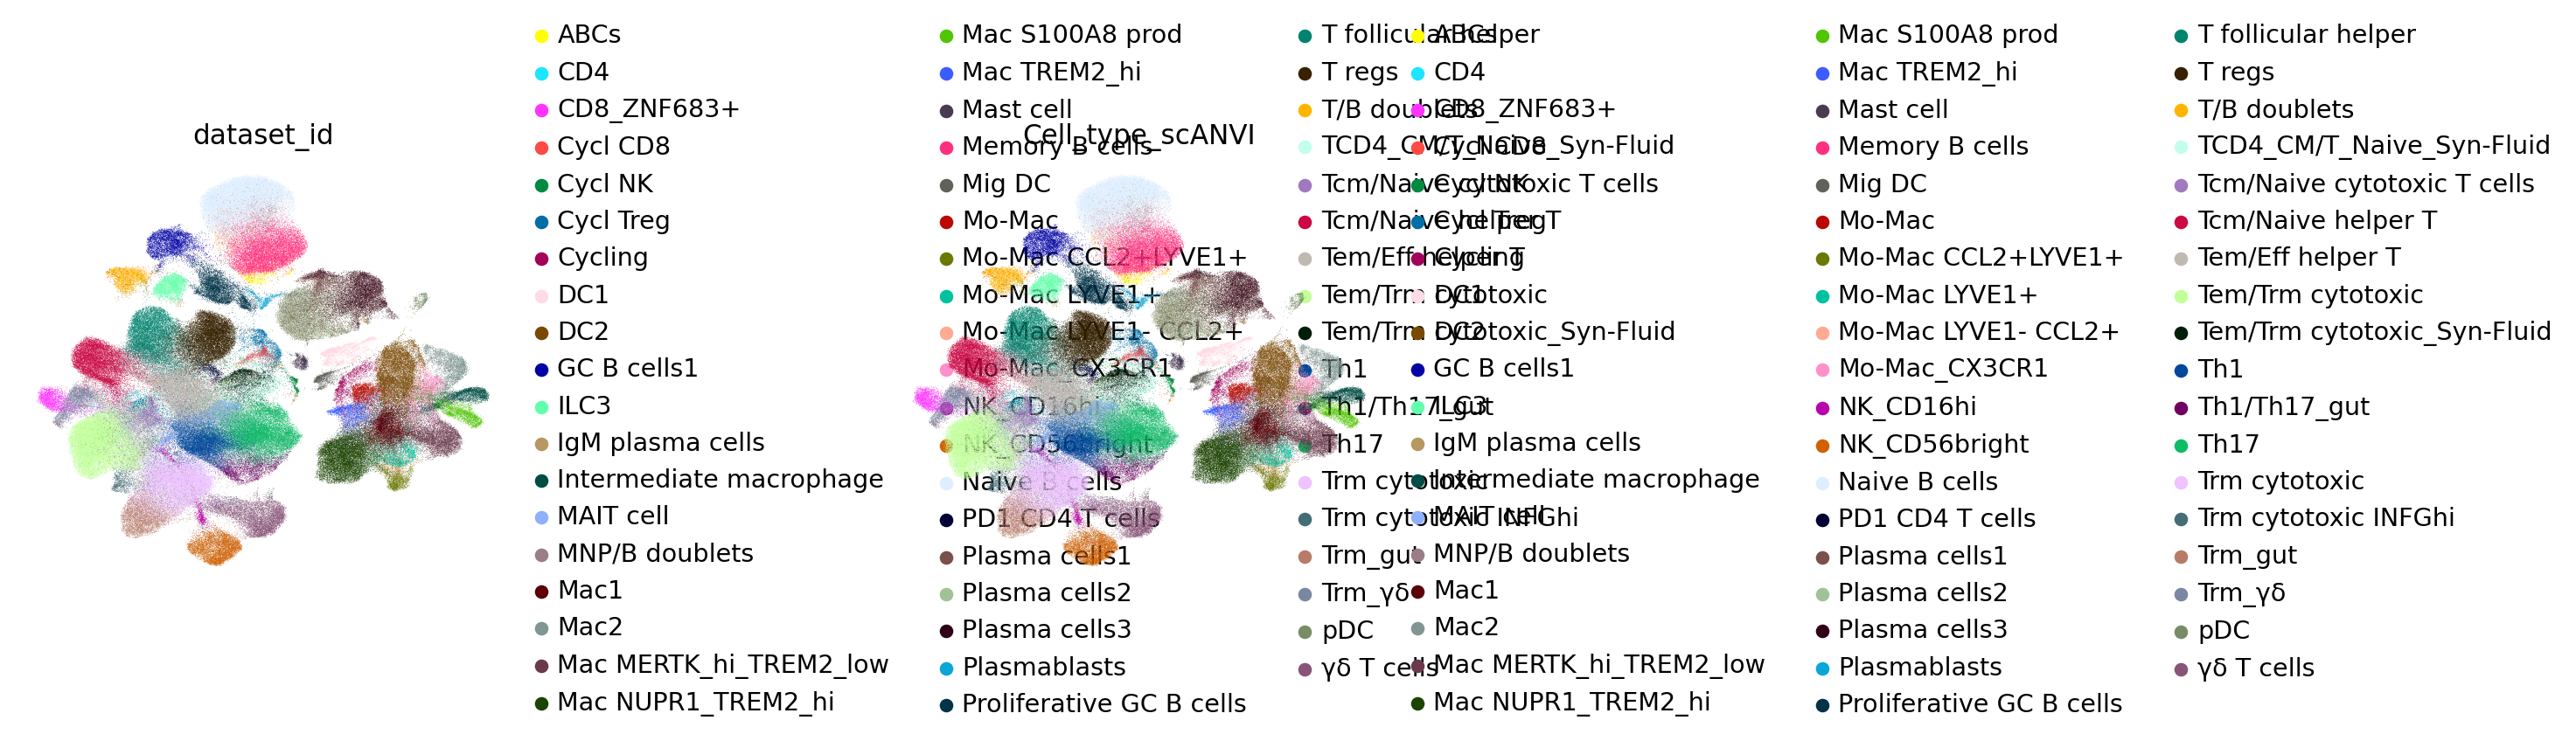

In [32]:
sc.pp.neighbors(reference_latent, n_neighbors=8)
sc.tl.leiden(reference_latent)
sc.tl.umap(reference_latent)
sc.pl.umap(reference_latent,
           color=['dataset_id', 'Cell_type_scANVI'],
           frameon=False,
           wspace=0.6,
           )

In [33]:
reference_latent.obs['predictions'] = scanvae.predict()
print("Acc: {}".format(np.mean(reference_latent.obs.predictions == reference_latent.obs.Cell_type_scANVI)))

Acc: 0.8391497331621044


In [34]:
ref_path = 'ref_model_tissue_for_skin/'
scanvae.save(ref_path, overwrite=True)

In [35]:
pd.DataFrame(adata_ref.var_names, columns=["Genes"]).to_csv("ref_model_tissue_for_skin/var_names.csv")

## Surgery with the query dataset

In [36]:
adata_query = adata_query.copy()

In [37]:
model = sca.models.SCANVI.load_query_data(
    adata_query,
    ref_path,
    freeze_dropout = True,
)
model._unlabeled_indices = np.arange(adata_query.n_obs)
model._labeled_indices = []
print("Labelled Indices: ", len(model._labeled_indices))
print("Unlabelled Indices: ", len(model._unlabeled_indices))

INFO     File ref_model_tissue_for_skin/model.pt already downloaded                                                
Labelled Indices:  0
Unlabelled Indices:  254314


In [38]:
model.train(
    max_epochs=50,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

INFO     Training for 50 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [30:26<00:00, 37.24s/it, v_num=1, train_loss_step=1.26e+3, train_loss_epoch=1.16e+3]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [30:26<00:00, 36.53s/it, v_num=1, train_loss_step=1.26e+3, train_loss_epoch=1.16e+3]


In [39]:
query_latent = sc.AnnData(model.get_latent_representation())
query_latent.obs['Cell_type_scANVI'] = adata_query.obs['Cell_type_scANVI'].tolist()

In [41]:
adata_query

AnnData object with n_obs × n_vars = 254314 × 2000
    obs: 'disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', '_scvi_batch', 'Cell_type_scANVI', '_scvi_labels'
    var: 'gene_ids-SKN8090524', 'feature_types-SKN8090524'
    uns: '_scvi_uuid', '_scvi_manager_uuid'

In [ ]:
sc.pp.neighbors(query_latent)
sc.tl.leiden(query_latent)
sc.tl.umap(query_latent)
plt.figure()
sc.pl.umap(
    query_latent,
    color=["dataset_id", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)

In [42]:
surgery_path = 'surgery_model_tissue_skin'
model.save(surgery_path, overwrite=True)

## Latent representation of reference + query dataset and compute UMAP

In [43]:
adata_full = adata_ref.concatenate(adata_query, batch_key="ref_query")
adata_full

AnnData object with n_obs × n_vars = 619517 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'ref_query'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'gene_s

In [ ]:
full_latent = sc.AnnData(model.get_latent_representation(adata=adata_full))
full_latent.obs['Cell_type_scANVI'] = adata_full.obs["Cell_type_scANVI"].tolist()
full_latent.obs['donor_id'] = adata_full.obs['donor_id'].tolist()

In [ ]:
full_latent.obs['dataset_id'] = adata_full.obs['dataset_id'].tolist()

In [ ]:

sc.pp.neighbors(full_latent)
sc.tl.leiden(full_latent)
sc.tl.umap(full_latent)
plt.figure()
sc.pl.umap(
    full_latent,
    color=["dataset_id", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)

In [ ]:
full_latent.obs['predictions'] = model.predict(adata=adata_full)

In [ ]:
sc.pp.neighbors(full_latent)
sc.tl.leiden(full_latent)
sc.tl.umap(full_latent)
plt.figure()
sc.pl.umap(
    full_latent,
    color=["predictions", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)

In [ ]:
full_latent

In [ ]:
full_latent[full_latent.obs.Cell_type_scANVI != "Cell_type_scANVI"].obs["predictions"].value_counts()

In [ ]:
adata_query.obs.disease.value_counts()

In [45]:
adata_query.obs

,disease_status,Site,tissue_harmo,Enrichment,Location,donor_id,sex,age,development_stage,cell_type,tissue,_scvi_batch,Cell_type_scANVI,_scvi_labels
index,,,,,,,,,,,,,,
AAACCTGGTCTCAACA-1-SKN8090524,Eczema,non_lesion,Epidermis,Live_single_spike,Lower_back,E2,Female,62.0,adult,nan,Epidermis,216,Unknown,56
AAACCTGGTGCTTCTC-1-SKN8090524,Eczema,non_lesion,Epidermis,Live_single_spike,Lower_back,E2,Female,62.0,adult,nan,Epidermis,216,Unknown,56
AAAGATGGTGTGAAAT-1-SKN8090524,Eczema,non_lesion,Epidermis,Live_single_spike,Lower_back,E2,Female,62.0,adult,nan,Epidermis,216,Unknown,56
AAAGATGGTTACTGAC-1-SKN8090524,Eczema,non_lesion,Epidermis,Live_single_spike,Lower_back,E2,Female,62.0,adult,nan,Epidermis,216,Unknown,56
AAAGCAACATCACAAC-1-SKN8090524,Eczema,non_lesion,Epidermis,Live_single_spike,Lower_back,E2,Female,62.0,adult,nan,Epidermis,216,Unknown,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCGCCTGTT-1-4820STDY7389014,Healthy,non_lesion,Epidermis,Lymphocytes,Breast,S3,Female,NaN,adult,Th,Epidermis,224,Unknown,56
TTTGTCAAGCGACGTA-1-4820STDY7389014,Healthy,non_lesion,Epidermis,Lymphocytes,Breast,S3,Female,NaN,adult,nan,Epidermis,224,Unknown,56
TTTGTCAAGGAATCGC-1-4820STDY7389014,Healthy,non_lesion,Epidermis,Lymphocytes,Breast,S3,Female,NaN,adult,Th,Epidermis,224,Unknown,56


In [46]:
adata_query.obs["tissue_harmo"].value_counts()

Dermis       142719
Epidermis    111595
Name: tissue_harmo, dtype: int64

In [61]:
adata_query.obs.columns


Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       '_scvi_batch', 'Cell_type_scANVI', '_scvi_labels'],
      dtype='object')

In [73]:
adata_query.obs["dataset_id"] = "Skin_Reynolds_et_al"

In [63]:
adata_query.obs["disease"] = adata_query.obs["disease_tissue"] 

In [62]:
adata_query.obs["disease_tissue"] = adata_query.obs["disease_status"].astype("str") + "_" + adata_query.obs["tissue_harmo"].astype("str")

adata_query.obs["disease_tissue"] = adata_query.obs["disease_tissue"].astype("category")

In [55]:
adata_ref.obs.disease_tissue.value_counts()

Paed_IBD_colon                  23299
hashimoto_thyroid               20035
Paed_IBD_ileum                  10720
CD_ileum                         9474
Uninfl_CD_ileum                  7345
Paed_Healthy_ileum               7334
CD_spondyloarthritis_colon        932
Healthy_colon                     818
CD_colon                          778
Resitant_treat_RA_syno_membr      691
spondyloarhtriti_colon            553
Remission_RA_syno_membr           232
Naïve_treat_RA_syno_membr         123
Name: disease_tissue, dtype: int64

In [53]:
adata_query.obs.Site.value_counts()

non_lesion    175123
lesion         79191
Name: Site, dtype: int64

In [159]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

In [74]:
adata_full = adata_ref.concatenate(adata_query, batch_key="ref_query")
adata_full

AnnData object with n_obs × n_vars = 619517 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'ref_query'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'gene_s

In [75]:
adata_full.obs.disease.value_counts(dropna=False)

Uninflam_CD                   88829
Eczema_Epidermis              57942
Paediatric IBD                57503
Healthy_Dermis                55036
Healthy_Epidermis             47076
Eczema_Dermis                 46389
Crohn's Disease               45659
Psoriasis_Dermis              41294
Psoriatic arthritis           41043
Hashimoto’s thyroiditis       33413
Rheumatoid Arthritis          29631
Healthy                       25704
Oligoarticular JIA            18862
Paed_Healthy                  13266
Undifferentiated Arthritis     6910
Psoriasis_Epidermis            6577
Spondyloarhtritis              2445
CD + Spondyloarthritis         1938
Name: disease, dtype: int64

In [76]:
adata_full.obs["disease_label_trans"] = adata_full.obs.disease.astype("str") + "_" + adata_full.obs.tissue_harmo.astype("str")

In [77]:
adata_full.obs['disease_label_trans'].value_counts(dropna = False)

Uninflam_CD_Ileum                               74829
Eczema_Epidermis_Epidermis                      57942
Healthy_Dermis_Dermis                           55036
Healthy_Epidermis_Epidermis                     47076
Eczema_Dermis_Dermis                            46389
Psoriasis_Dermis_Dermis                         41294
Psoriatic arthritis_Synovial fluid              40392
Paediatric IBD_Colon                            37406
Crohn's Disease_Ileum                           35742
Hashimoto’s thyroiditis_Thyroid                 33413
Rheumatoid Arthritis_Synovial membrane          29631
Paediatric IBD_Ileum                            20097
Oligoarticular JIA_Synovial fluid               18862
Uninflam_CD_Colon                               14000
Healthy_Colon                                   13835
Paed_Healthy_Ileum                              13266
Crohn's Disease_Colon                            9917
Undifferentiated Arthritis_Synovial membrane     6910
Healthy_Ileum               

In [78]:
adata_full.obs['disease'].value_counts(dropna = False)

Uninflam_CD                   88829
Eczema_Epidermis              57942
Paediatric IBD                57503
Healthy_Dermis                55036
Healthy_Epidermis             47076
Eczema_Dermis                 46389
Crohn's Disease               45659
Psoriasis_Dermis              41294
Psoriatic arthritis           41043
Hashimoto’s thyroiditis       33413
Rheumatoid Arthritis          29631
Healthy                       25704
Oligoarticular JIA            18862
Paed_Healthy                  13266
Undifferentiated Arthritis     6910
Psoriasis_Epidermis            6577
Spondyloarhtritis              2445
CD + Spondyloarthritis         1938
Name: disease, dtype: int64

In [79]:
adata_full.obs['predictions'] = model.predict(adata=adata_full)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [80]:
adata_full.obs[['disease_label_trans', 'predictions']].value_counts()

disease_label_trans                     predictions                
Eczema_Dermis_Dermis                    Mast cell                      27165
Eczema_Epidermis_Epidermis              Mast cell                      18767
Uninflam_CD_Ileum                       Trm cytotoxic                  11305
Paediatric IBD_Colon                    Naive B cells                  10800
Healthy_Epidermis_Epidermis             Tem/Trm cytotoxic_Syn-Fluid    10115
                                                                       ...  
Healthy_Synovial membrane               Mo-Mac_CX3CR1                      1
Eczema_Dermis_Dermis                    Proliferative GC B cells           1
                                        Trm_gut                            1
Healthy_Synovial membrane               Mast cell                          1
Rheumatoid Arthritis_Synovial membrane  IgM plasma cells                   1
Length: 1093, dtype: int64

In [81]:
adata_full.obs.dataset_id.value_counts(dropna=False)

Skin_Reynolds_et_al            254314
Kong_et_al_2023                101054
GSE134809_Martin_et_al_2019     47390
E-MTAB-8322_Stefeno_2020        41573
E-MTAB-9492_Penkava_2020        38906
GSE121380_Huang_2019            37406
Elmentaite_2020                 34902
Qian_Yue_Zhang_2022             33413
Martin_JIA_2019                 18862
GSE163314_Lefferts_2021          9560
GSE161500_Abji_2020              2137
Name: dataset_id, dtype: int64

In [82]:
adata_full.obs.Cell_type_scANVI.value_counts()

Unknown                        254314
Tem/Trm cytotoxic               25831
Trm cytotoxic                   24807
Naive B cells                   21693
Th17                            19936
Tem/Eff helper T                19195
T regs                          15089
Memory B cells                  14690
Th1                             14476
Tcm/Naive helper T              13136
T follicular helper             13106
Mac NUPR1_TREM2_hi              13065
DC2                             10791
Plasma cells1                    9885
Plasma cells2                    9014
γδ T cells                       8625
Mac1                             7422
Plasma cells3                    6881
Mac MERTK_hi_TREM2_low           6789
NK_CD56bright                    6394
Proliferative GC B cells         6391
Trm_gut                          5944
MAIT cell                        5659
GC B cells1                      5140
Mac2                             4848
Trm_γδ                           4631
Tcm/Naive cy

In [83]:
pd.DataFrame(adata_full.obs).to_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu_with_Skin_data.csv")

In [86]:
!pwd 

/home/jupyter/data


In [ ]:
!rclone copy ../data/ 'gdrive:Projects/gcp_gpu/data_gpu/'

In [87]:
!rclone copy Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu_with_Skin_data.csv\
'gdrive:gcp_gpu/data_gpu/'

In [88]:
!rclone copy surgery_model_tissue_skin/\
'gdrive:gcp_gpu/data_gpu/surgery_model_tissue_skin/'

In [89]:
!rclone copy ref_model_tissue_for_skin/\
'gdrive:gcp_gpu/data_gpu/ref_model_tissue_for_skin/'

         Falling back to preprocessing with `sc.pp.pca` and default params.


<Figure size 320x320 with 0 Axes>

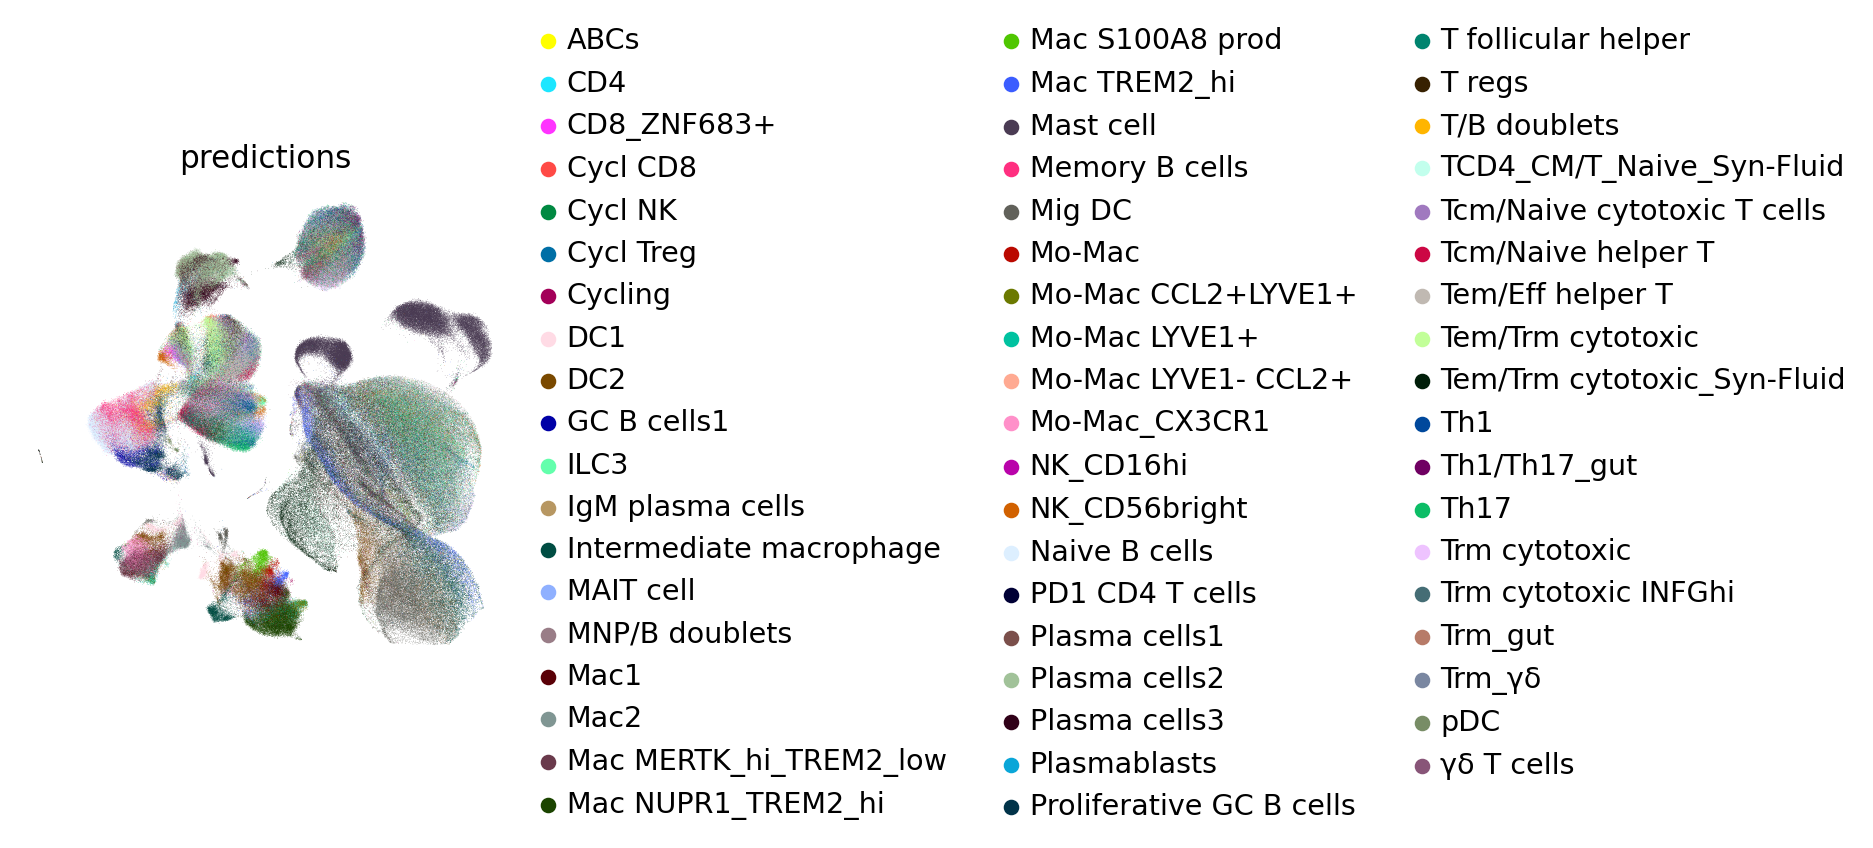

In [90]:
sc.pp.neighbors(adata_full)
sc.tl.leiden(adata_full)
sc.tl.umap(adata_full)
plt.figure()
sc.pl.umap(
    adata_full,
    color=["predictions"],
    frameon=False,
    wspace=0.6,
)